In [3]:
#import and dataset
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Reproducibility
np.random.seed(42)

# Load MNIST
(X_train, _), (_, _) = mnist.load_data()

# Flatten + normalize
X_train = X_train.reshape(-1, 784) / 255.0

# RBM needs binary inputs
X_rbm = (X_train > 0.5).astype(float)


In [5]:
#RBM initialzation
visible_units = 784
hidden_units = 64

W = 0.01 * np.random.randn(visible_units, hidden_units)
bv = np.zeros((1, visible_units))
bh = np.zeros((1, hidden_units))


In [6]:
#Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


In [7]:
#sampling functions
def sample_h(v):
    prob_h = sigmoid(v @ W + bh)
    h = (prob_h > np.random.rand(*prob_h.shape)).astype(float)
    return prob_h, h

def sample_v(h):
    prob_v = sigmoid(h @ W.T + bv)
    v = (prob_v > np.random.rand(*prob_v.shape)).astype(float)
    return prob_v, v


In [9]:
#Contrastive divergence(CD-1)
def cd1(v0, lr=0.01):
    global W, bv, bh

    # Positive phase
    ph0, h0 = sample_h(v0)

    # Negative phase
    pv1, v1 = sample_v(h0)
    ph1, _ = sample_h(v1)

    # Updates
    W += lr * ((v0.T @ ph0) - (v1.T @ ph1)) / v0.shape[0]
    bv += lr * np.mean(v0 - v1, axis=0, keepdims=True)
    bh += lr * np.mean(ph0 - ph1, axis=0, keepdims=True)

    # Reconstruction error
    error = np.mean((v0 - v1) ** 2)
    return error


In [10]:
#train the RBM
epochs = 10
batch_size = 64
rbm_errors = []

for epoch in range(epochs):
    idx = np.random.permutation(len(X_rbm))
    X_shuffled = X_rbm[idx]

    epoch_error = 0

    for i in range(0, len(X_shuffled), batch_size):
        v0 = X_shuffled[i:i+batch_size]
        epoch_error += cd1(v0, lr=0.01)

    rbm_errors.append(epoch_error)
    print(f"Epoch {epoch+1}, Reconstruction Error: {epoch_error:.4f}")


Epoch 1, Reconstruction Error: 177.4167
Epoch 2, Reconstruction Error: 126.8594
Epoch 3, Reconstruction Error: 113.6665
Epoch 4, Reconstruction Error: 105.9740
Epoch 5, Reconstruction Error: 100.6223
Epoch 6, Reconstruction Error: 96.7287
Epoch 7, Reconstruction Error: 93.5915
Epoch 8, Reconstruction Error: 91.0201
Epoch 9, Reconstruction Error: 88.9955
Epoch 10, Reconstruction Error: 87.1210


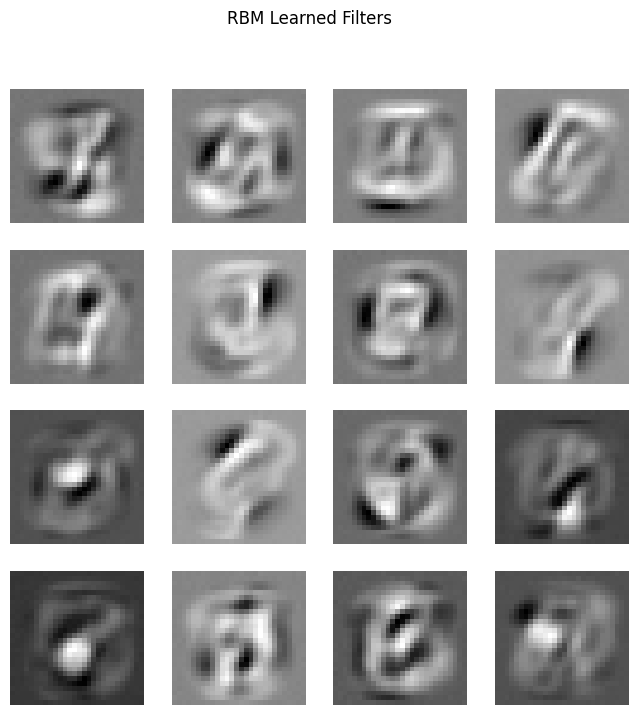

In [12]:
#RBM learned filters
plt.figure(figsize=(8,8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(W[:, i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.suptitle("RBM Learned Filters")
plt.show()


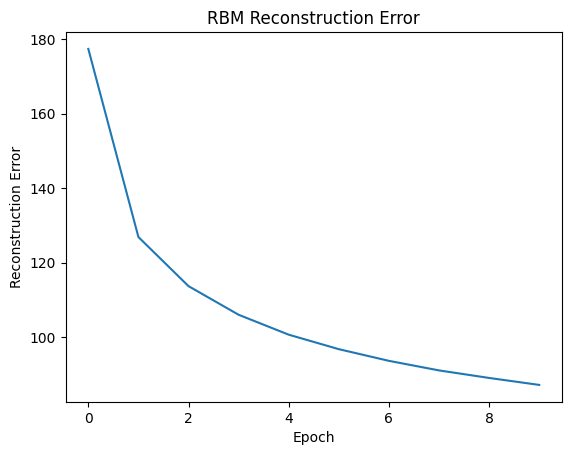

In [13]:
#RBM reconstruction error plot
plt.plot(rbm_errors)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Error")
plt.title("RBM Reconstruction Error")
plt.show()
